In [24]:
from csp import CSP, backtracking_search, AC3

# Define KSA regions and their adjacency 
regions = ['Najran', 'Jazan', 'Asir', 'Makkah', 'Riyadh', 'Eastern', 'Qassim', 'Hail', 'Tabuk', 'Madinah', 'Northern', 'Al-Baha']
adjacencies = {
    'Najran': ['Jazan', 'Asir'],
    'Jazan': ['Najran', 'Asir', 'Makkah'],
    'Asir': ['Najran', 'Jazan', 'Makkah', 'Al-Baha'],  
    'Makkah': ['Jazan', 'Asir', 'Riyadh', 'Eastern', 'Al-Baha'], 
    'Riyadh': ['Makkah', 'Eastern', 'Qassim', 'Hail'],
    'Eastern': ['Makkah', 'Riyadh'],
    'Qassim': ['Riyadh', 'Hail'],
    'Hail': ['Riyadh', 'Qassim', 'Tabuk'],
    'Tabuk': ['Hail', 'Madinah'],
    'Madinah': ['Tabuk', 'Makkah'],
    'Northern': ['Makkah'],
    'Al-Baha': ['Asir', 'Makkah']  
}

# Define the domains (colors)
colors = ['Red', 'Green', 'Blue']

# Define the Map Coloring CSP problem
def map_coloring_csp():
    # Variables (regions)
    variables = regions
    
    # Domains (colors) - each region gets the list of colors
    domains = {region: colors for region in regions}
    
    # Neighbors (adjacencies) - adjacency relationships
    neighbors = adjacencies
    
    # Constraints: No two adjacent regions should have the same color
    def adjacent_constraint(Xi, x, Xj, y):
        return x != y  # regions should not have the same color
    
    # Create a CSP instance with the required parameters
    csp = CSP(variables, domains, neighbors, adjacent_constraint)
    
    return csp

# Create the CSP problem instance
csp_problem = map_coloring_csp()

# Apply Arc Consistency (AC-3)
AC3(csp_problem)

# Solve the problem using Backtracking Search
solution = backtracking_search(csp_problem)

# Print the solution
if solution:
    for region, color in solution.items():
        print(f"{region}: {color}")
else:
    print("No solution found.")


Najran: Red
Jazan: Green
Asir: Blue
Makkah: Red
Riyadh: Green
Eastern: Blue
Qassim: Red
Hail: Blue
Tabuk: Red
Madinah: Green
Northern: Green
Al-Baha: Green


In [ ]:
pip install matplotlib geopandas


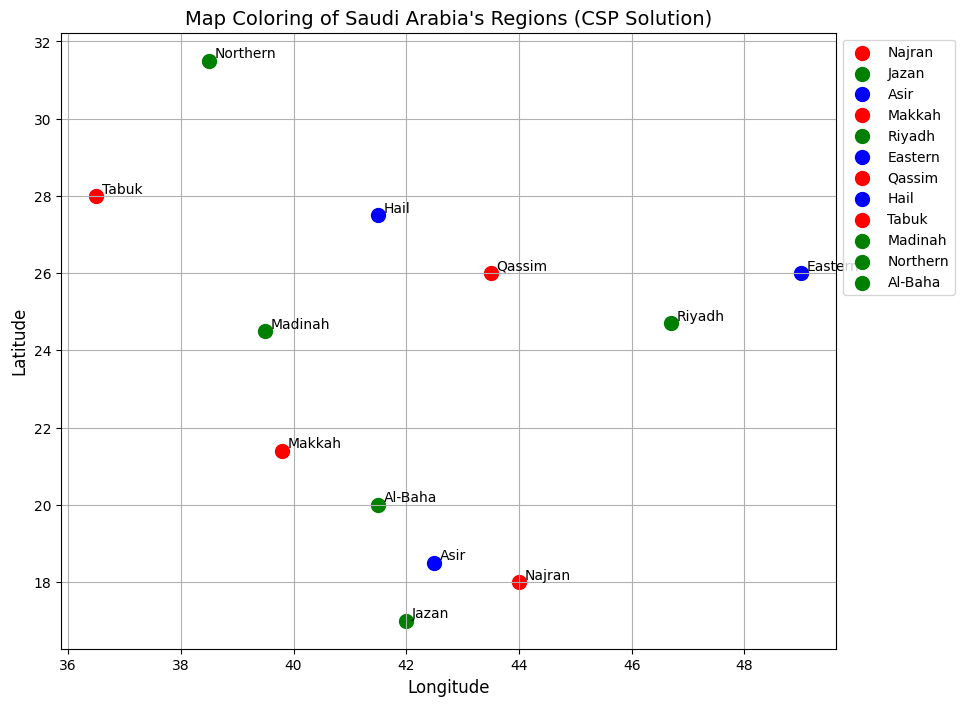

In [27]:
import matplotlib.pyplot as plt

# Define the regions and their assigned colors from the CSP solution
solution = {
    'Najran': 'Red',
    'Jazan': 'Green',
    'Asir': 'Blue',
    'Makkah': 'Red',
    'Riyadh': 'Green',
    'Eastern': 'Blue',
    'Qassim': 'Red',
    'Hail': 'Blue',
    'Tabuk': 'Red',
    'Madinah': 'Green',
    'Northern': 'Green',
    'Al-Baha': 'Green'
}

# Coordinates for plotting the regions (these are simplified coordinates, not exact geographic positions)
region_coordinates = {
    'Najran': (18.0, 44.0),
    'Jazan': (17.0, 42.0),
    'Asir': (18.5, 42.5),
    'Makkah': (21.4, 39.8),
    'Riyadh': (24.7, 46.7),
    'Eastern': (26.0, 49.0),
    'Qassim': (26.0, 43.5),
    'Hail': (27.5, 41.5),
    'Tabuk': (28.0, 36.5),
    'Madinah': (24.5, 39.5),
    'Northern': (31.5, 38.5),
    'Al-Baha': (20.0, 41.5)
}

# Plotting the map with region labels and assigned colors
plt.figure(figsize=(10, 8))

# Plot each region with its corresponding color
for region, (lat, lon) in region_coordinates.items():
    plt.scatter(lon, lat, color=solution[region], s=100, label=region)  # Points for regions
    plt.text(lon + 0.1, lat, region, fontsize=10, ha='left', va='bottom')  # Region label

# Adding title and axis labels
plt.title("Map Coloring of Saudi Arabia's Regions (CSP Solution)", fontsize=14)
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

# Show plot
plt.grid(True)
plt.show()
